# 🔬 Revisión de Recomendaciones — CAP Sleep Database

Este notebook recorre **cada recomendación del diagnóstico exploratorio** y verifica su estado sobre los CSVs ya generados.
No requiere los archivos EDF originales: trabaja con los seis CSVs de salida del diagnóstico.

| # | Recomendación |
|---|---------------|
| 1 | Ampliar `CHANNEL_MAPPING` (canales UNKNOWN) |
| 2 | Verificar alias de canales en pacientes sin EEG / ECG |
| 3 | Evaluar viabilidad del análisis respiratorio |
| 4 | Inspeccionar pacientes con saturación EEG al 100% |
| 5 | Separar señales de rango fijo del análisis de saturación |
| 6 | Evaluar clipping en señales respiratorias |
| 7 | Planificar resampleo a frecuencia objetivo |
| 8 | Verificar cobertura de anotaciones para tiempo de sueño efectivo |


## 0 · Imports y carga de datos

Ajusta `OUT_DIR` a la carpeta donde guardaste los CSVs del diagnóstico.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

# ── AJUSTA ESTA RUTA ──────────────────────────────────────────────────────
OUT_DIR = Path('../data/diagnostico_outputs')   # carpeta con los 6 CSVs
# ─────────────────────────────────────────────────────────────────────────

# Carga
matriz    = pd.read_csv(OUT_DIR / '01_matriz_canales.csv', index_col=0)
cat_summ  = pd.read_csv(OUT_DIR / '02_resumen_categorias.csv')
sat_canal = pd.read_csv(OUT_DIR / '03_saturacion_por_canal.csv')
sat_pac   = pd.read_csv(OUT_DIR / '04_saturacion_por_paciente.csv')
sfreq_df  = pd.read_csv(OUT_DIR / '05_frecuencias_muestreo.csv')
inv       = pd.read_csv(OUT_DIR / '06_inventario_canales_raw.csv')

print(f'✅ CSVs cargados')
print(f'   inv:       {len(inv):>5} filas')
print(f'   sat_pac:   {len(sat_pac):>5} filas')
print(f'   sfreq_df:  {len(sfreq_df):>5} filas')


✅ CSVs cargados
   inv:        2074 filas
   sat_pac:    2074 filas
   sfreq_df:    108 filas


# 🗂️ 1. Ampliar CHANNEL_MAPPING

Propuesta de mapeo para los 305 canales clasificados como UNKNOWN. Revisa la tabla, ajusta el diccionario y ejecuta la celda de validación para ver cuántos UNKNOWN quedan.


### 1.1 Diagnóstico: canales UNKNOWN más frecuentes


In [2]:
unknown_counts = (
    inv[inv['category'] == 'UNKNOWN']['channel']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'canal', 'channel': 'n_archivos'})
)
# compatibilidad pandas ≥ 2.0
if 'canal' not in unknown_counts.columns:
    unknown_counts.columns = ['canal', 'n_archivos']

print(f'Canales UNKNOWN distintos: {len(unknown_counts)}')
print(f'Entradas UNKNOWN totales : {len(inv[inv["category"]=="UNKNOWN"])}')
display(unknown_counts.head(30))


Canales UNKNOWN distintos: 69
Entradas UNKNOWN totales : 305


,canal,n_archivos
0,HR,88
1,STAT,74
2,TIB DX,6
3,TIB SX,5
4,O2-A1,4
5,LOC,4
6,ROC,4
7,LOC-ROC,3
8,F2-F4,3
9,TERMISTORE,3


### 1.2 Propuesta de mapeo extendido

> **Instrucción:** revisa el diccionario, ajusta las categorías que no te convenzcan y ejecuta la celda siguiente.


In [3]:
# ── EDITA AQUÍ según tu criterio clínico ─────────────────────────────────
EXTENDED_MAPPING = {
    # Frecuencia cardíaca / oximetría
    'HR':              'OXYGEN',
    'HEART RATE VARIA':'OXYGEN',
    # Canal de estado / eventos — se descarta del análisis de señal
    'STAT':            'IGNORE',
    'TAG':             'IGNORE',
    'THE':             'IGNORE',
    # EMG tibial anterior
    'TIB DX':          'EMG',
    'TIB SX':          'EMG',
    # EOG — variantes sin guión estándar
    'LOC':             'EOG',
    'ROC':             'EOG',
    'LOC-ROC':         'EOG',
    'LOC-A1':          'EOG',
    'ROC-A2':          'EOG',
    'EOG-L':           'EOG',
    'EOG-R':           'EOG',
    # EEG — derivaciones con referencia ipsilateral sin guión
    'F3A2':            'EEG',
    'F4A1':            'EEG',
    'C3A2':            'EEG',
    'C4A1':            'EEG',
    'O1A2':            'EEG',
    'O2A1':            'EEG',
    'O2-A1':           'EEG',
    'F2-F4':           'EEG',
    'T4':              'EEG',
    # EMG submentoniano — sin formato estándar
    'CHIN1':           'EMG',
    'CHIN2':           'EMG',
    # Flujo nasal — variantes italianas / sin normalizar
    'TERMISTORO':      'FLOW',
    'TERMISTORE':      'FLOW',
    'FLUSSO-0':        'FLOW',
    'FLUSSO-1':        'FLOW',
    'CANULA':          'FLOW',
    'FLATTENING':      'FLOW',
    # Posición corporal — italiano
    'POSIZIONE':       'OTHER',
    # Otros aún sin clasificar
    'MILO':            'UNKNOWN',
    'ECG2':            'ECG',
    'DX1':             'OTHER',
    'DX2':             'OTHER',
    'SX1':             'OTHER',
    'SX2':             'OTHER',
}
# ─────────────────────────────────────────────────────────────────────────
print(f'Entradas en EXTENDED_MAPPING: {len(EXTENDED_MAPPING)}')


Entradas en EXTENDED_MAPPING: 38


### 1.3 Validación: ¿cuántos UNKNOWN quedan?


In [4]:
inv_v2 = inv.copy()
inv_v2['category_v2'] = inv_v2.apply(
    lambda r: EXTENDED_MAPPING.get(r['channel'], r['category']),
    axis=1
)

antes  = (inv['category'] == 'UNKNOWN').sum()
despues = (inv_v2['category_v2'] == 'UNKNOWN').sum()
resueltos = antes - despues

print(f'UNKNOWN antes  : {antes}')
print(f'UNKNOWN después: {despues}  ({despues/len(inv)*100:.1f}% del total)')
print(f'Resueltos      : {resueltos} ({resueltos/antes*100:.1f}% del bloque UNKNOWN)')

if despues > 0:
    print('\nCanales aún sin mapear:')
    display(
        inv_v2[inv_v2['category_v2'] == 'UNKNOWN']['channel']
        .value_counts().reset_index()
    )
else:
    print('\n✅ Todos los canales están mapeados.')


UNKNOWN antes  : 305
UNKNOWN después: 55  (2.7% del total)
Resueltos      : 250 (82.0% del bloque UNKNOWN)

Canales aún sin mapear:


,channel,count
0,MILO,2
1,EMG-EMG,2
2,C3,2
3,C4,2
4,O1,2
5,O2,2
6,A1,2
7,A2,2
8,ECG1,2
9,EMG1,2


### 1.4 Disponibilidad recalculada con el mapeo extendido


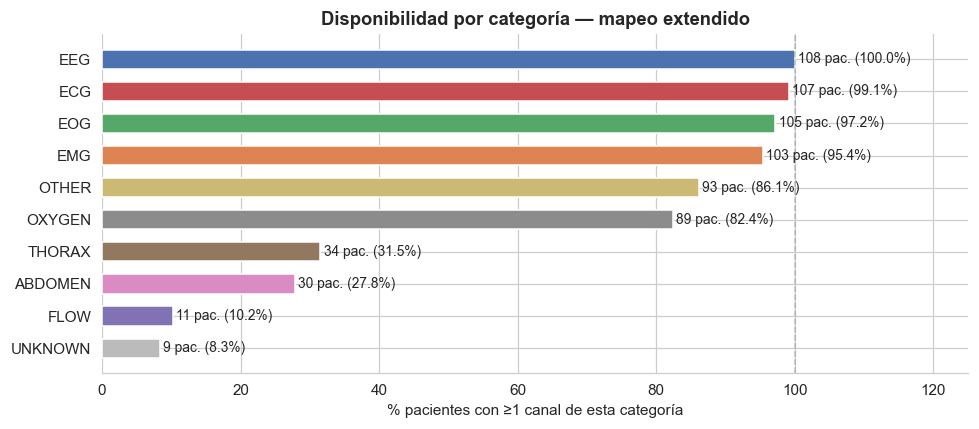

In [5]:
n_pat = inv_v2['patient'].nunique()
cat_v2 = (
    inv_v2[inv_v2['category_v2'] != 'IGNORE']
    .drop_duplicates(['patient', 'category_v2'])
    .groupby('category_v2')['patient'].nunique()
    .reset_index()
    .rename(columns={'category_v2': 'categoria', 'patient': 'n_pacientes'})
    .assign(pct=lambda x: (x['n_pacientes'] / n_pat * 100).round(1))
    .sort_values('n_pacientes', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
COLORS = {
    'EEG':'#4C72B0','EMG':'#DD8452','EOG':'#55A868','ECG':'#C44E52',
    'FLOW':'#8172B3','THORAX':'#937860','ABDOMEN':'#DA8BC3',
    'OXYGEN':'#8C8C8C','OTHER':'#CCB974','UNKNOWN':'#BBBBBB',
}
colors = [COLORS.get(c, '#BBBBBB') for c in cat_v2['categoria']]
bars = ax.barh(cat_v2['categoria'], cat_v2['pct'], color=colors, height=0.6, edgecolor='white')
for bar, (_, row) in zip(bars, cat_v2.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['n_pacientes']} pac. ({row['pct']}%)",
            va='center', ha='left', fontsize=9)
ax.axvline(100, color='#999', lw=1, ls='--', alpha=0.6)
ax.set_xlim(0, 125)
ax.set_xlabel('% pacientes con ≥1 canal de esta categoría')
ax.set_title('Disponibilidad por categoría — mapeo extendido', fontweight='bold')
ax.invert_yaxis()
sns.despine(left=True); ax.tick_params(left=False)
plt.tight_layout(); plt.show()


# 🔍 2. Verificar alias en pacientes sin EEG o ECG

Para cada paciente que el diagnóstico marcó como 'sin EEG' o 'sin ECG', listamos todos sus canales para detectar si existe la señal bajo otro nombre.


In [6]:
cat_pivot = (
    inv.drop_duplicates(['patient','category'])
    .pivot_table(index='patient', columns='category', values='channel', aggfunc='count')
    .fillna(0)
)

no_eeg = cat_pivot[cat_pivot.get('EEG', pd.Series(0, index=cat_pivot.index)) == 0].index.tolist()
no_ecg = cat_pivot[cat_pivot.get('ECG', pd.Series(0, index=cat_pivot.index)) == 0].index.tolist()

print(f'Pacientes sin EEG ({len(no_eeg)}): {no_eeg}')
print(f'Pacientes sin ECG ({len(no_ecg)}): {no_ecg}')


Pacientes sin EEG (5): ['n13', 'n14', 'n15', 'nfle25', 'nfle33']
Pacientes sin ECG (3): ['n16', 'nfle25', 'nfle33']


### 2.1 Canales completos de pacientes sin EEG

Busca nombres que sean derivaciones EEG sin guión (e.g. `C3A2`, `F3A2`) o con referencia no estándar.


In [7]:
print('=' * 60)
for pat in no_eeg:
    canales = inv[inv['patient'] == pat][['channel','category']].drop_duplicates()
    posibles_eeg = canales[
        canales['channel'].str.contains(
            r'^(F[34]|C[34]|O[12]|P[34]|FP[12]|FZ|CZ|PZ)',
            regex=True, case=False, na=False
        )
    ]
    print(f'\n── {pat} ──')
    print(canales.to_string(index=False))
    if not posibles_eeg.empty:
        print(f'  ⚠️  Posibles EEG sin mapear: {posibles_eeg["channel"].tolist()}')



── n13 ──
channel category
    LOC  UNKNOWN
    ROC  UNKNOWN
  CHIN1  UNKNOWN
  CHIN2  UNKNOWN
   F3A2  UNKNOWN
   F4A1  UNKNOWN
   C3A2  UNKNOWN
   C4A1  UNKNOWN
   O1A2  UNKNOWN
   O2A1  UNKNOWN
    ECG      ECG
  ⚠️  Posibles EEG sin mapear: ['F3A2', 'F4A1', 'C3A2', 'C4A1', 'O1A2', 'O2A1']

── n14 ──
channel category
    LOC  UNKNOWN
    ROC  UNKNOWN
  CHIN1  UNKNOWN
  CHIN2  UNKNOWN
   F3A2  UNKNOWN
   F4A1  UNKNOWN
   C3A2  UNKNOWN
   C4A1  UNKNOWN
   O1A2  UNKNOWN
   O2A1  UNKNOWN
    ECG      ECG
  ⚠️  Posibles EEG sin mapear: ['F3A2', 'F4A1', 'C3A2', 'C4A1', 'O1A2', 'O2A1']

── n15 ──
channel category
  EOG-L  UNKNOWN
  EOG-R  UNKNOWN
  CHIN1  UNKNOWN
  CHIN2  UNKNOWN
   F3A2  UNKNOWN
   F4A1  UNKNOWN
   C3A2  UNKNOWN
   C4A1  UNKNOWN
   O1A2  UNKNOWN
   O2A1  UNKNOWN
    EKG      ECG
  ⚠️  Posibles EEG sin mapear: ['F3A2', 'F4A1', 'C3A2', 'C4A1', 'O1A2', 'O2A1']

── nfle25 ──
 channel category
POSITION    OTHER
  TIB SX  UNKNOWN
  TIB DX  UNKNOWN
     MIC    OTHER
      C3  U

C:\Users\LilyG\AppData\Local\Temp\ipykernel_19864\3294348426.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  canales['channel'].str.contains(
C:\Users\LilyG\AppData\Local\Temp\ipykernel_19864\3294348426.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  canales['channel'].str.contains(
C:\Users\LilyG\AppData\Local\Temp\ipykernel_19864\3294348426.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  canales['channel'].str.contains(
C:\Users\LilyG\AppData\Local\Temp\ipykernel_19864\3294348426.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  canales['channel'].str.contains(
C:\Users\LilyG\AppData\Local\Temp\ipykernel_19864\3294348426

### 2.2 Canales completos de pacientes sin ECG


In [8]:
print('=' * 60)
for pat in no_ecg:
    canales = inv[inv['patient'] == pat][['channel','category']].drop_duplicates()
    posibles_ecg = canales[
        canales['channel'].str.contains(
            r'(ECG|EKG|CARD|HEART)',
            regex=True, case=False, na=False
        )
    ]
    print(f'\n── {pat} ──')
    print(canales.to_string(index=False))
    if not posibles_ecg.empty:
        print(f'  ⚠️  Posibles ECG sin mapear: {posibles_ecg["channel"].tolist()}')



── n16 ──
channel category
 FP2-F4      EEG
  F4-C4      EEG
  C4-P4      EEG
  P4-O2      EEG
  C4-A1      EEG

── nfle25 ──
 channel category
POSITION    OTHER
  TIB SX  UNKNOWN
  TIB DX  UNKNOWN
     MIC    OTHER
      C3  UNKNOWN
      C4  UNKNOWN
      O1  UNKNOWN
      O2  UNKNOWN
      A1  UNKNOWN
      A2  UNKNOWN
     ROC  UNKNOWN
     LOC  UNKNOWN
    ECG1  UNKNOWN
    ECG2  UNKNOWN
    EMG1  UNKNOWN
    EMG2  UNKNOWN
     FP2  UNKNOWN
      F4  UNKNOWN
      P4  UNKNOWN
     FP1  UNKNOWN
      F3  UNKNOWN
      P3  UNKNOWN
      F8  UNKNOWN
      T4  UNKNOWN
      T6  UNKNOWN
      F7  UNKNOWN
      T5  UNKNOWN
      T3  UNKNOWN
  TORACE   THORAX
 ADDDOME  ABDOMEN
    STAT  UNKNOWN
      HR  UNKNOWN
    SAO2   OXYGEN
   PLETH   OXYGEN
  ⚠️  Posibles ECG sin mapear: ['ECG1', 'ECG2']

── nfle33 ──
 channel category
POSITION    OTHER
     DX1  UNKNOWN
     DX2  UNKNOWN
     MIC    OTHER
      C3  UNKNOWN
      C4  UNKNOWN
    ECG1  UNKNOWN
    ECG2  UNKNOWN
      A1  UNKNOWN
 

C:\Users\LilyG\AppData\Local\Temp\ipykernel_19864\2681544155.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  canales['channel'].str.contains(
C:\Users\LilyG\AppData\Local\Temp\ipykernel_19864\2681544155.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  canales['channel'].str.contains(
C:\Users\LilyG\AppData\Local\Temp\ipykernel_19864\2681544155.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  canales['channel'].str.contains(


### 2.3 Decisión por paciente

> Completa la tabla con tu decisión: `incluir` si encontraste el canal bajo otro nombre, `excluir` si confirmas ausencia.


In [ ]:
# ── EDITA AQUÍ ───────────────────────────────────────────────────────────
decision_eeg = {
    'n13':    'pendiente',   # saturación 100% — ver sección 4
    'n14':    'pendiente',   # saturación 100% — ver sección 4
    'n15':    'pendiente',
    'nfle25': 'pendiente',
    'nfle33': 'pendiente',
}
decision_ecg = {
    'n16':    'pendiente',
    'nfle25': 'pendiente',
    'nfle33': 'pendiente',
}
# ─────────────────────────────────────────────────────────────────────────

for label, d in [('EEG', decision_eeg), ('ECG', decision_ecg)]:
    excluidos = [p for p, v in d.items() if v == 'excluir']
    pendientes = [p for p, v in d.items() if v == 'pendiente']
    print(f'{label} — excluidos: {excluidos}  |  pendientes: {pendientes}')


# 🫁 3. Evaluar viabilidad del análisis respiratorio

FLOW solo está disponible en el 5.6% de la cohorte. Esta sección identifica qué subgrupos tienen señales respiratorias y si la oximetría puede servir de proxy.


In [9]:
resp_cats = ['FLOW', 'THORAX', 'ABDOMEN', 'OXYGEN']
resp_df = (
    inv[inv['category'].isin(resp_cats)]
    .drop_duplicates(['patient','category'])
    .pivot_table(index='patient', columns='category', values='channel', aggfunc='count')
    .fillna(0).astype(int)
    .reindex(columns=resp_cats, fill_value=0)
)

# Añadir grupo (prefijo del patient id)
resp_df['grupo'] = resp_df.index.str.extract(r'^([a-zA-Z]+)')[0]
resp_df = resp_df.sort_values('grupo')

print('Cobertura de señales respiratorias y oximetría por paciente:')
display(resp_df)


Cobertura de señales respiratorias y oximetría por paciente:


category,FLOW,THORAX,ABDOMEN,OXYGEN,grupo
patient,,,,,
ins1,1,1,1,1,NaN
ins2,0,0,0,1,NaN
ins3,0,1,1,0,NaN
ins5,0,0,0,1,NaN
ins6,0,0,0,1,NaN
...,...,...,...,...,...
rbd9,0,0,0,1,NaN
sdb1,1,1,1,1,NaN
sdb2,1,1,1,1,NaN


In [10]:
# Resumen por grupo
grp = resp_df.groupby('grupo')[resp_cats].apply(lambda x: (x > 0).sum())
grp_n = resp_df.groupby('grupo').size().rename('n_pacientes')
grp_summ = grp.join(grp_n)

print('Disponibilidad por grupo diagnóstico:')
display(grp_summ)

# Pacientes con al menos FLOW o ambas bandas (THORAX + ABDOMEN)
tiene_flow = resp_df['FLOW'] > 0
tiene_bandas = (resp_df['THORAX'] > 0) & (resp_df['ABDOMEN'] > 0)
tiene_resp = tiene_flow | tiene_bandas
tiene_oxygen = resp_df['OXYGEN'] > 0

print(f'\nPacientes con FLOW o (THORAX+ABDOMEN): {tiene_resp.sum()} / {len(resp_df)}')
print(f'Pacientes con OXYGEN (proxy):           {tiene_oxygen.sum()} / {len(resp_df)}')
print(f'Pacientes con resp. completa Y oxygen:  {(tiene_resp & tiene_oxygen).sum()}')


Disponibilidad por grupo diagnóstico:


,FLOW,THORAX,ABDOMEN,OXYGEN,n_pacientes
grupo,,,,,



Pacientes con FLOW o (THORAX+ABDOMEN): 31 / 94
Pacientes con OXYGEN (proxy):           88 / 94
Pacientes con resp. completa Y oxygen:  25


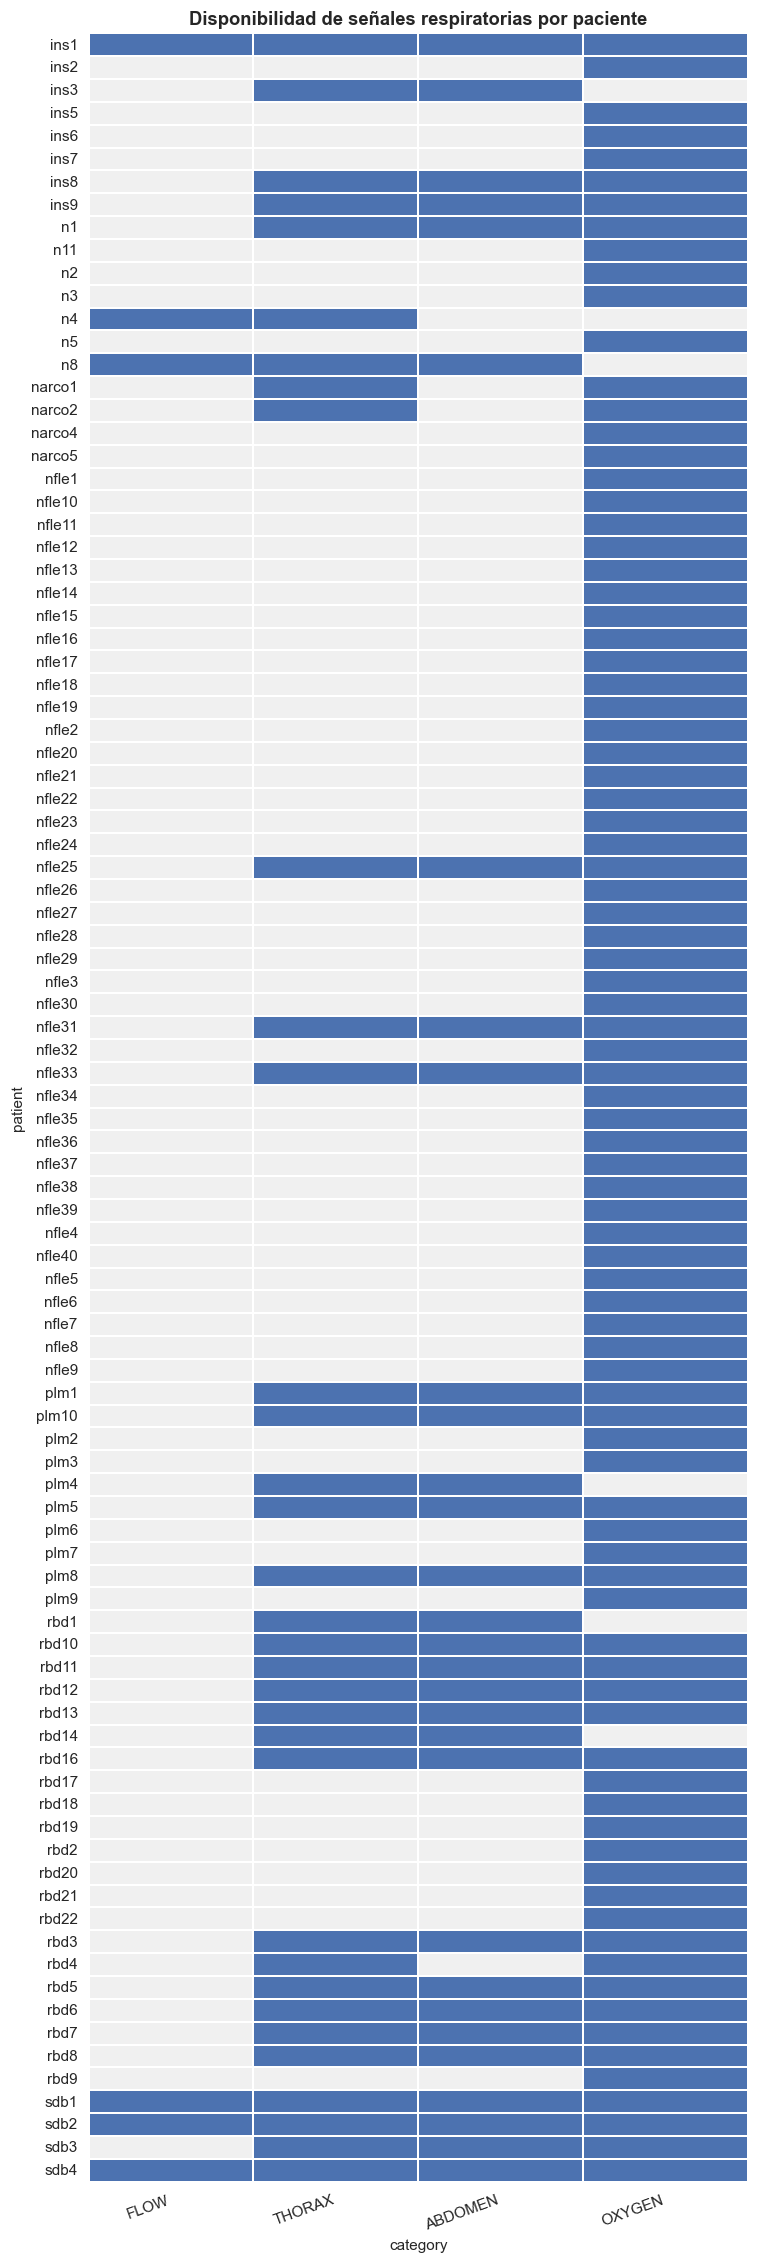

In [11]:
# Heatmap de disponibilidad respiratoria
fig, ax = plt.subplots(figsize=(7, max(4, len(resp_df) * 0.22)))
cmap = sns.color_palette(['#F0F0F0', '#8172B3', '#937860', '#DA8BC3', '#8C8C8C'])
plot_data = resp_df[resp_cats].copy()
# Normalizar a 0/1 para el heatmap
plot_data = (plot_data > 0).astype(int)
sns.heatmap(plot_data, cmap=['#F0F0F0','#4C72B0'], linewidths=0.3,
            linecolor='white', cbar=False, ax=ax)
ax.set_title('Disponibilidad de señales respiratorias por paciente', fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()


### 3.1 Conclusión de viabilidad

> **Acción recomendada:** Si vas a analizar eventos respiratorios (apneas, hipopneas), filtra la cohorte a los pacientes con FLOW o con THORAX+ABDOMEN.
> Para el resto, OXYGEN (SpO₂) puede usarse como proxy indirecto de eventos.


In [12]:
pacientes_respiratorios = resp_df[tiene_resp].index.tolist()
pacientes_solo_oxygen   = resp_df[~tiene_resp & tiene_oxygen].index.tolist()
pacientes_sin_resp      = resp_df[~tiene_resp & ~tiene_oxygen].index.tolist()

print(f'Subgrupo con señal respiratoria directa ({len(pacientes_respiratorios)}): {pacientes_respiratorios}')
print(f'Subgrupo solo oximetría ({len(pacientes_solo_oxygen)}): {pacientes_solo_oxygen}')
print(f'Sin ninguna señal respiratoria ({len(pacientes_sin_resp)}): {pacientes_sin_resp}')


Subgrupo con señal respiratoria directa (31): ['ins1', 'ins3', 'ins8', 'ins9', 'n1', 'n4', 'n8', 'nfle25', 'nfle31', 'nfle33', 'plm1', 'plm10', 'plm4', 'plm5', 'plm8', 'rbd1', 'rbd10', 'rbd11', 'rbd12', 'rbd13', 'rbd14', 'rbd16', 'rbd3', 'rbd5', 'rbd6', 'rbd7', 'rbd8', 'sdb1', 'sdb2', 'sdb3', 'sdb4']
Subgrupo solo oximetría (63): ['ins2', 'ins5', 'ins6', 'ins7', 'n11', 'n2', 'n3', 'n5', 'narco1', 'narco2', 'narco4', 'narco5', 'nfle1', 'nfle10', 'nfle11', 'nfle12', 'nfle13', 'nfle14', 'nfle15', 'nfle16', 'nfle17', 'nfle18', 'nfle19', 'nfle2', 'nfle20', 'nfle21', 'nfle22', 'nfle23', 'nfle24', 'nfle26', 'nfle27', 'nfle28', 'nfle29', 'nfle3', 'nfle30', 'nfle32', 'nfle34', 'nfle35', 'nfle36', 'nfle37', 'nfle38', 'nfle39', 'nfle4', 'nfle40', 'nfle5', 'nfle6', 'nfle7', 'nfle8', 'nfle9', 'plm2', 'plm3', 'plm6', 'plm7', 'plm9', 'rbd17', 'rbd18', 'rbd19', 'rbd2', 'rbd20', 'rbd21', 'rbd22', 'rbd4', 'rbd9']
Sin ninguna señal respiratoria (0): []


# ⚡ 4. Inspeccionar pacientes con saturación EEG al 100%

Los pacientes n13 y n14 presentan todos sus canales EEG saturados. Esta sección los aisla, muestra el detalle y genera un veredicto de exclusión.


In [13]:
# Señales que saturan por diseño (rango fijo) — se excluyen del análisis
RANGO_FIJO = {'SAO2','SPO2','HR','PLETH','POSITION','POSIZIONE','STAT','TAG',
              'HEART RATE VARIA','FLUSSO-0','FLUSSO-1'}

sat_eeg = sat_pac[
    ~sat_pac['channel'].isin(RANGO_FIJO) &
    (sat_pac['category'].isin(['EEG','EMG','EOG','ECG']) |
     sat_pac['channel'].isin(['F3A2','F4A1','C3A2','C4A1','O1A2','O2A1',
                              'LOC','ROC','CHIN1','CHIN2']))
].copy()

# Pacientes con algún canal EEG al 100%
sat100 = sat_eeg[sat_eeg['pct_saturated'] == 100.0]
pats_sat100 = sat100['patient'].unique()
print(f'Pacientes con ≥1 canal EEG al 100% de saturación: {pats_sat100}')


Pacientes con ≥1 canal EEG al 100% de saturación: <StringArray>
['n13', 'n14']
Length: 2, dtype: str


In [14]:
for pat in pats_sat100:
    df_pat = sat_eeg[sat_eeg['patient'] == pat][
        ['channel','category','n_samples','n_saturated','pct_saturated']
    ].sort_values('pct_saturated', ascending=False)
    total_ch = len(df_pat)
    ch_sat = (df_pat['pct_saturated'] == 100).sum()
    print(f'\n{'='*55}')
    print(f'Paciente: {pat}  |  canales al 100%: {ch_sat}/{total_ch}')
    display(df_pat)
    if ch_sat == total_ch:
        print(f'  ❌  TODOS los canales EEG/ECG saturados → candidato a EXCLUSIÓN')
    else:
        print(f'  ⚠️  Saturación parcial → revisar manualmente')



Paciente: n13  |  canales al 100%: 10/11


,channel,category,n_samples,n_saturated,pct_saturated
244,LOC,UNKNOWN,5885400,5885400,100.0000
245,ROC,UNKNOWN,5885400,5885400,100.0000
246,CHIN1,UNKNOWN,5885400,5885400,100.0000
247,CHIN2,UNKNOWN,5885400,5885400,100.0000
248,F3A2,UNKNOWN,5885400,5885400,100.0000
249,F4A1,UNKNOWN,5885400,5885400,100.0000
250,C3A2,UNKNOWN,5885400,5885400,100.0000
251,C4A1,UNKNOWN,5885400,5885400,100.0000
252,O1A2,UNKNOWN,5885400,5885400,100.0000
253,O2A1,UNKNOWN,5885400,5885400,100.0000


  ⚠️  Saturación parcial → revisar manualmente

Paciente: n14  |  canales al 100%: 11/11


,channel,category,n_samples,n_saturated,pct_saturated
255,LOC,UNKNOWN,5910200,5910200,100.0
256,ROC,UNKNOWN,5910200,5910200,100.0
257,CHIN1,UNKNOWN,5910200,5910200,100.0
258,CHIN2,UNKNOWN,5910200,5910200,100.0
259,F3A2,UNKNOWN,5910200,5910200,100.0
260,F4A1,UNKNOWN,5910200,5910200,100.0
261,C3A2,UNKNOWN,5910200,5910200,100.0
262,C4A1,UNKNOWN,5910200,5910200,100.0
263,O1A2,UNKNOWN,5910200,5910200,100.0
264,O2A1,UNKNOWN,5910200,5910200,100.0


  ❌  TODOS los canales EEG/ECG saturados → candidato a EXCLUSIÓN


### 4.1 Veredicto de exclusión

> Completa el diccionario según tu inspección manual de los EDF.


In [ ]:
# ── EDITA AQUÍ tras revisar los EDF manualmente ──────────────────────────
veredicto = {
    'n13': 'excluir',    # todos los canales EEG/ECG al 100%
    'n14': 'excluir',    # todos los canales EEG/ECG al 100%
}
# ─────────────────────────────────────────────────────────────────────────

excluidos_sat = [p for p, v in veredicto.items() if v == 'excluir']
print(f'Pacientes excluidos por saturación total: {excluidos_sat}')

# Lista limpia de pacientes
todos = sfreq_df['patient'].tolist()
cohorte_limpia = [p for p in todos if p not in excluidos_sat]
print(f'Cohorte tras exclusión: {len(cohorte_limpia)} / {len(todos)} pacientes')


# 📊 5. Separar señales de rango fijo del análisis de saturación

SAO2, HR y PLETH saturan por diseño. Esta sección propone umbrales diferenciados y genera una tabla de saturación filtrada solo para canales EEG/EMG/EOG/ECG.


In [15]:
# Clasificación de canales por tipo de umbral
CATEGORIAS_EEG = ['EEG', 'EMG', 'EOG', 'ECG']
CATEGORIAS_RANGO_FIJO = ['OXYGEN']
CANALES_IGNORAR = RANGO_FIJO | {'POSITION', 'POSIZIONE', 'STAT', 'TAG', 'THE'}

sat_por_tipo = sat_pac.copy()
sat_por_tipo['tipo'] = sat_por_tipo.apply(
    lambda r: 'rango_fijo' if r['channel'] in CANALES_IGNORAR or r['category'] in CATEGORIAS_RANGO_FIJO
    else ('señal_neural' if r['category'] in CATEGORIAS_EEG
          else 'respiratorio_otro'),
    axis=1
)

resumen_tipo = (
    sat_por_tipo.groupby('tipo')
    .agg(
        n_entradas=('pct_saturated', 'count'),
        sat_media=('pct_saturated', 'mean'),
        sat_max=('pct_saturated', 'max'),
        entradas_sat=('pct_saturated', lambda x: (x > 0).sum()),
    )
    .round(2)
)
display(resumen_tipo)


,n_entradas,sat_media,sat_max,entradas_sat
tipo,,,,
rango_fijo,366,81.50,100.0,351
respiratorio_otro,408,12.42,100.0,222
señal_neural,1300,0.24,100.0,418


In [16]:
# Saturación filtrada — solo señales neurales
sat_neural = sat_por_tipo[sat_por_tipo['tipo'] == 'señal_neural'].copy()

# Resumen por canal
sat_neural_agg = (
    sat_neural.groupby(['channel','category'])
    .agg(
        n_pacientes=('patient','nunique'),
        sat_media=('pct_saturated','mean'),
        sat_max=('pct_saturated','max'),
        pacs_con_sat=('pct_saturated', lambda x: (x > 0).sum()),
    )
    .round(3)
    .reset_index()
    .sort_values('sat_media', ascending=False)
)
sat_neural_agg['flag'] = sat_neural_agg['sat_media'].apply(lambda x: '⚠️' if x > 1 else '')

print('Canales neurales con saturación media > 0%:')
display(sat_neural_agg[sat_neural_agg['sat_media'] > 0])


Canales neurales con saturación media > 0%:


,channel,category,n_pacientes,sat_media,sat_max,pacs_con_sat,flag
4,ECG,ECG,5,39.921,100.000,2,⚠️
6,EKG,ECG,4,25.091,99.970,3,⚠️
5,ECG1-ECG2,ECG,96,0.099,2.502,78,
17,ROC-LOC,EOG,96,0.030,1.779,52,
8,EMG1-EMG2,EMG,96,0.014,0.586,30,
19,T4-T6,EEG,45,0.012,0.434,13,
12,F8-T4,EEG,68,0.009,0.434,21,
16,P4-O2,EEG,99,0.008,0.342,30,
2,C4-A1,EEG,99,0.006,0.361,34,
3,C4-P4,EEG,99,0.004,0.187,23,


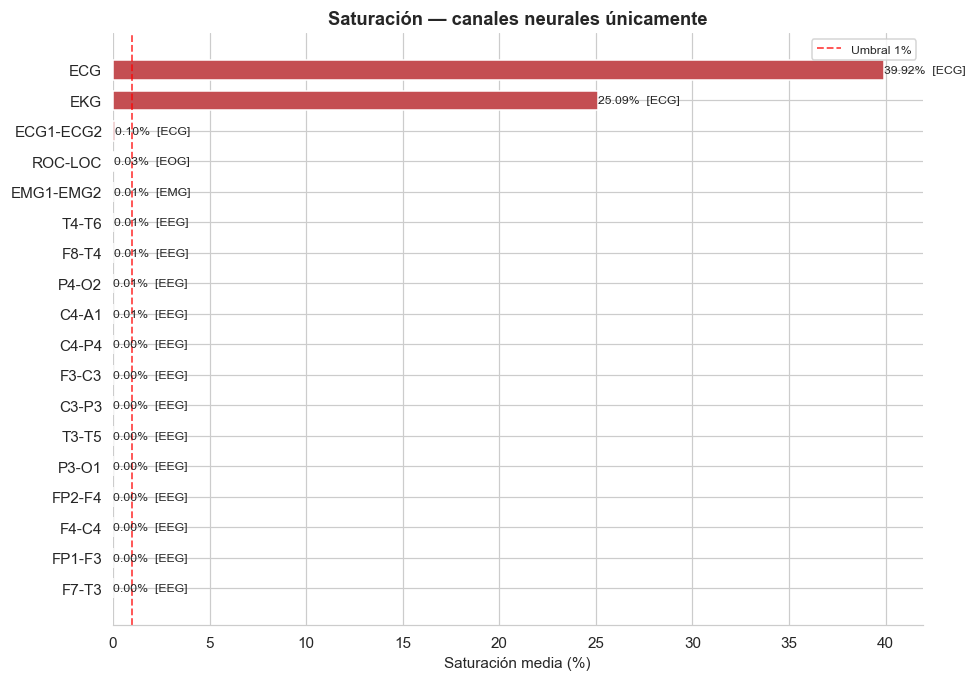

In [17]:
# Gráfico de saturación — solo canales neurales
top = sat_neural_agg[sat_neural_agg['sat_media'] > 0].head(20)
if top.empty:
    print('✅ Sin saturación en canales neurales.')
else:
    COLORS = {'EEG':'#4C72B0','EMG':'#DD8452','EOG':'#55A868','ECG':'#C44E52'}
    colors = [COLORS.get(c,'#BBBBBB') for c in top['category']]
    fig, ax = plt.subplots(figsize=(9, max(3, len(top)*0.35)))
    bars = ax.barh(top['channel'], top['sat_media'], color=colors, edgecolor='white', height=0.65)
    for bar, (_, row) in zip(bars, top.iterrows()):
        ax.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                f"{row['sat_media']:.2f}%  [{row['category']}]",
                va='center', ha='left', fontsize=8)
    ax.axvline(1.0, color='red', lw=1.2, ls='--', alpha=0.7, label='Umbral 1%')
    ax.set_xlabel('Saturación media (%)')
    ax.set_title('Saturación — canales neurales únicamente', fontweight='bold')
    ax.invert_yaxis(); ax.legend(fontsize=8)
    sns.despine(left=True); ax.tick_params(left=False)
    plt.tight_layout(); plt.show()


# 🌬️ 6. Evaluar clipping en señales respiratorias

FLUSSO, ADDOME y TORACE muestran saturaciones elevadas (19–44%). Esta sección evalúa la distribución por paciente y sugiere si se puede rescatar la señal.


In [18]:
resp_channels = ['FLUSSO','TORACE','ADDOME','ADDDOME','ABDO',
                 'FLOW','THORAX','ABDOMEN','CANNULA','CANULA',
                 'TERMISTORE','FLATTENING','FLUSSO-0','FLUSSO-1']

sat_resp = sat_pac[sat_pac['channel'].isin(resp_channels)].copy()

print(f'Entradas respiratorias en sat_pac: {len(sat_resp)}')
print(f'Pacientes con señal respiratoria  : {sat_resp["patient"].nunique()}')
display(sat_resp.sort_values('pct_saturated', ascending=False))


Entradas respiratorias en sat_pac: 77
Pacientes con señal respiratoria  : 34


,patient,channel,category,n_samples,n_saturated,pct_saturated
330,n4,CANNULA,FLOW,7148000,7147859,99.9980
336,n4,FLOW,FLOW,7148000,7147778,99.9969
387,n8,FLOW,FLOW,6008000,6007599,99.9933
2019,sdb1,FLUSSO,FLOW,7234560,6641522,91.8027
335,n4,FLATTENING,UNKNOWN,7148000,6274167,87.7751
...,...,...,...,...,...,...
1092,nfle33,TORACE,THORAX,15897600,0,0.0000
875,nfle25,TORACE,THORAX,8017920,0,0.0000
876,nfle25,ADDDOME,ABDOMEN,8017920,0,0.0000
1933,rbd6,TERMISTORE,UNKNOWN,27955200,0,0.0000


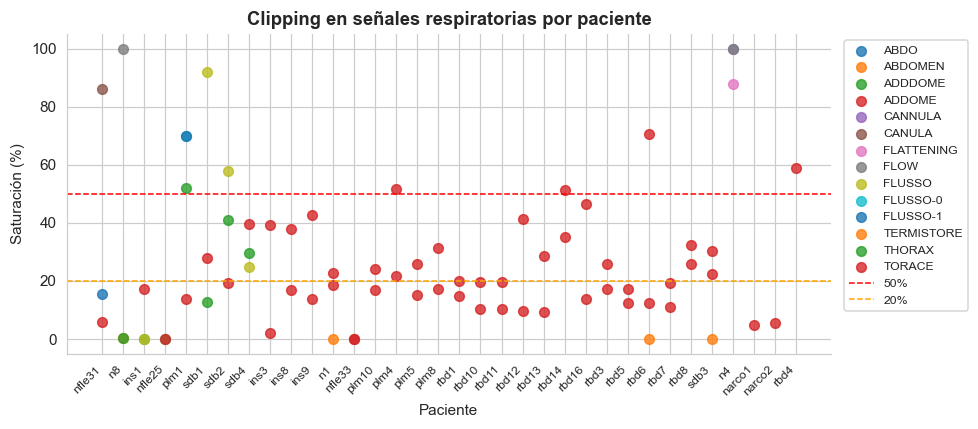

In [19]:
if sat_resp.empty:
    print('No hay canales respiratorios en el dataset.')
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    for canal, grp in sat_resp.groupby('channel'):
        ax.scatter(grp['patient'], grp['pct_saturated'], label=canal, s=40, alpha=0.8)
    ax.axhline(50, color='red', lw=1, ls='--', label='50%')
    ax.axhline(20, color='orange', lw=1, ls='--', label='20%')
    ax.set_xlabel('Paciente')
    ax.set_ylabel('Saturación (%)')
    ax.set_title('Clipping en señales respiratorias por paciente', fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8, bbox_to_anchor=(1.01,1))
    sns.despine(); plt.tight_layout(); plt.show()


### 6.1 Diagnóstico de usabilidad

> Un canal con saturación >50% tiene más de la mitad de sus muestras clippeadas → **descartar para eventos respiratorios cuantitativos**.
> Entre 20–50% puede ser útil para detección binaria (presencia/ausencia de esfuerzo) pero no para cuantificación.
> <20% → señal recuperable con filtrado.


In [20]:
if not sat_resp.empty:
    sat_resp['usabilidad'] = pd.cut(
        sat_resp['pct_saturated'],
        bins=[-1, 20, 50, 101],
        labels=['recuperable (<20%)', 'parcial (20–50%)', 'descartar (>50%)']
    )
    display(sat_resp.groupby(['channel','usabilidad']).size().unstack(fill_value=0))


usabilidad,recuperable (<20%),parcial (20–50%),descartar (>50%)
channel,,,
ABDO,1,0,0
ABDOMEN,1,0,0
ADDDOME,3,2,1
ADDOME,12,7,3
CANNULA,0,0,1
CANULA,0,0,1
FLATTENING,0,0,1
FLOW,0,0,2
FLUSSO,1,1,2


# 📡 7. Planificar resampleo a frecuencia objetivo

La cohorte tiene 5 frecuencias distintas (100–512 Hz). Esta sección calcula el factor de resampleo para cada paciente y señala los casos con mayor pérdida de información.


In [21]:
# ── AJUSTA AQUÍ la frecuencia objetivo ───────────────────────────────────
TARGET_HZ = 256
# ─────────────────────────────────────────────────────────────────────────

sfreq_df['factor_resampleo'] = (TARGET_HZ / sfreq_df['sfreq_hz']).round(4)
sfreq_df['operacion'] = sfreq_df['sfreq_hz'].apply(
    lambda f: 'sin cambio' if f == TARGET_HZ
    else ('decimación' if f > TARGET_HZ else 'upsampling')
)
sfreq_df['riesgo'] = sfreq_df['sfreq_hz'].apply(
    lambda f: 'alto' if f < TARGET_HZ else ('ninguno' if f == TARGET_HZ else 'bajo')
)

display(sfreq_df[['patient','sfreq_hz','factor_resampleo','operacion','riesgo',
                   'duration_min','n_channels']].sort_values('sfreq_hz'))


,patient,sfreq_hz,factor_resampleo,operacion,riesgo,duration_min,n_channels
14,n12,100.0,2.56,upsampling,alto,495.00,9
18,n16,100.0,2.56,upsampling,alto,513.33,5
23,n6,128.0,2.00,upsampling,alto,527.08,8
26,n9,128.0,2.00,upsampling,alto,532.35,8
24,n7,128.0,2.00,upsampling,alto,492.33,8
...,...,...,...,...,...,...,...
99,rbd5,512.0,0.50,decimación,bajo,580.00,22
103,rbd9,512.0,0.50,decimación,bajo,591.02,20
102,rbd8,512.0,0.50,decimación,bajo,537.02,22
101,rbd7,512.0,0.50,decimación,bajo,527.02,23


In [22]:
# Resumen por frecuencia
resumen_freq = (
    sfreq_df.groupby(['sfreq_hz','operacion','riesgo'])
    .agg(n_pacientes=('patient','count'))
    .reset_index()
)
display(resumen_freq)

# Gráfico
freq_counts = sfreq_df['sfreq_hz'].value_counts().sort_index()
RIESGO_COLORS = {'sin cambio':'#55A868','decimación':'#4C72B0','upsampling':'#C44E52'}
op_map = sfreq_df.drop_duplicates('sfreq_hz').set_index('sfreq_hz')['operacion']
colors_bar = [RIESGO_COLORS[op_map[f]] for f in freq_counts.index]

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(freq_counts.index.astype(str), freq_counts.values,
              color=colors_bar, edgecolor='white')
for bar, val in zip(bars, freq_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, str(val),
            ha='center', va='bottom', fontsize=10)
ax.axvline(-0.5 + list(freq_counts.index).index(TARGET_HZ) if TARGET_HZ in freq_counts.index else -1,
           color='black', lw=0, ls='--')
patches = [mpatches.Patch(color=v, label=k) for k, v in RIESGO_COLORS.items()]
ax.legend(handles=patches, fontsize=9)
ax.set_xlabel('Frecuencia de muestreo original (Hz)')
ax.set_ylabel('N° pacientes')
ax.set_title(f'Distribución de frecuencias → objetivo {TARGET_HZ} Hz', fontweight='bold')
sns.despine(); plt.tight_layout(); plt.show()


,sfreq_hz,operacion,riesgo,n_pacientes
0,100.0,upsampling,alto,2
1,128.0,upsampling,alto,3
2,200.0,upsampling,alto,5
3,256.0,sin cambio,ninguno,17
4,512.0,decimación,bajo,81


ValueError: At least one value in the dash list must be positive

<Figure size 880x330 with 1 Axes>

### 7.1 Pacientes de riesgo alto (upsampling)

> Los pacientes que originalmente grabaron a frecuencia **inferior** al objetivo requieren **upsampling**,  lo que introduce interpolación y puede generar artefactos espectrales.
> Considera documentarlos como posible fuente de sesgo en el análisis.


In [23]:
riesgo_alto = sfreq_df[sfreq_df['riesgo'] == 'alto'][['patient','sfreq_hz','n_channels','duration_min']]
if riesgo_alto.empty:
    print(f'✅ No hay pacientes por debajo de {TARGET_HZ} Hz.')
else:
    print(f'⚠️  {len(riesgo_alto)} pacientes requieren upsampling ({TARGET_HZ} Hz → original):')
    display(riesgo_alto)


⚠️  10 pacientes requieren upsampling (256 Hz → original):


,patient,sfreq_hz,n_channels,duration_min
14,n12,100.0,9,495.00
15,n13,200.0,11,490.45
16,n14,200.0,11,492.52
17,n15,200.0,11,494.17
18,n16,100.0,5,513.33
21,n4,200.0,17,595.67
23,n6,128.0,8,527.08
24,n7,128.0,8,492.33
25,n8,200.0,14,500.67
26,n9,128.0,8,532.35


# 🕐 8. Verificar cobertura de anotaciones para tiempo de sueño efectivo

La duración del EDF varía entre 239 y 910 minutos. El análisis debe normalizarse por tiempo de sueño efectivo (TST), no por duración total. Esta sección explora la variabilidad de duración y establece la lista de archivos de anotaciones necesarios.


Duración de las grabaciones (minutos):
count    108.0
mean     557.8
std      105.6
min      239.0
25%      503.3
50%      527.0
75%      575.1
max      910.0


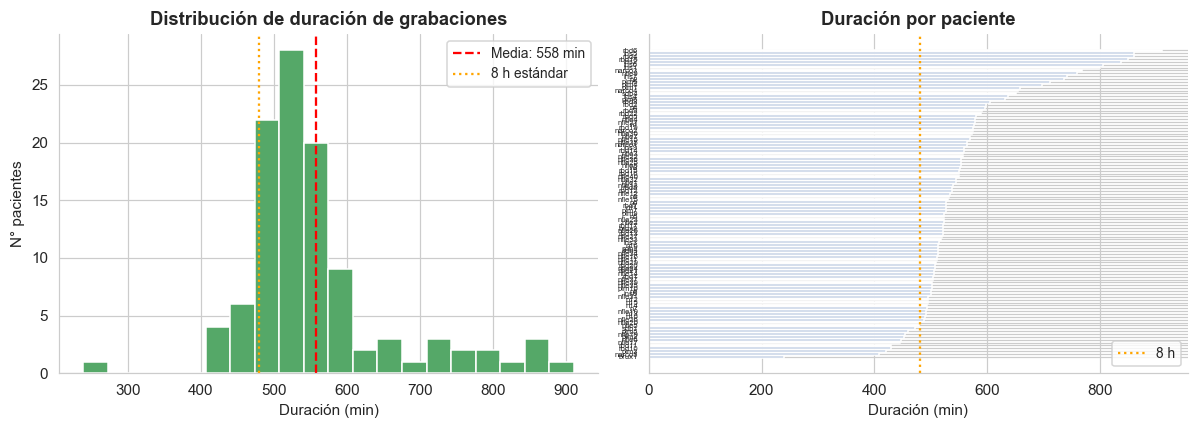

In [24]:
# Estadísticas de duración
dur = sfreq_df['duration_min']
print('Duración de las grabaciones (minutos):')
print(dur.describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(dur, bins=20, color='#55A868', edgecolor='white')
axes[0].axvline(dur.mean(), color='red', ls='--', lw=1.5, label=f'Media: {dur.mean():.0f} min')
axes[0].axvline(480, color='orange', ls=':', lw=1.5, label='8 h estándar')
axes[0].set_xlabel('Duración (min)'); axes[0].set_ylabel('N° pacientes')
axes[0].set_title('Distribución de duración de grabaciones', fontweight='bold')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

sfreq_df_sorted = sfreq_df.sort_values('duration_min')
axes[1].barh(sfreq_df_sorted['patient'], sfreq_df_sorted['duration_min'],
             color='#4C72B0', edgecolor='white', height=0.6)
axes[1].axvline(480, color='orange', ls=':', lw=1.5, label='8 h')
axes[1].set_xlabel('Duración (min)')
axes[1].set_title('Duración por paciente', fontweight='bold')
axes[1].tick_params(axis='y', labelsize=5)
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout(); plt.show()


### 8.1 Fuentes de anotaciones en la CAP Sleep Database

La base de datos incluye archivos de hipnograma (`.st` o anotaciones EDF+) para cada paciente.
El **tiempo total de sueño (TST)** se calcula sumando las épocas anotadas como N1, N2, N3 o REM.

**Para extraer el TST de cada paciente necesitas:**

```python
import mne
raw = mne.io.read_raw_edf('paciente.edf', preload=False)
annotations = raw.annotations  # o leer el .st con mne.read_annotations()
epocas_sueno = [a for a in annotations if a['description'] not in ['W','?']]
tst_min = sum(a['duration'] for a in epocas_sueno) / 60
```


In [25]:
# Pacientes con duración atípica
p5  = dur.quantile(0.05)
p95 = dur.quantile(0.95)
atipicos = sfreq_df[(dur < p5) | (dur > p95)][['patient','duration_min','sfreq_hz']]

print(f'Grabaciones cortas (<p5 = {p5:.0f} min): {(dur < p5).sum()} pacientes')
print(f'Grabaciones largas (>p95 = {p95:.0f} min): {(dur > p95).sum()} pacientes')
if not atipicos.empty:
    print('\nPacientes atípicos (revisar si el EDF fue cortado o contiene tiempo de setup):')
    display(atipicos)


Grabaciones cortas (<p5 = 446 min): 6 pacientes
Grabaciones largas (>p95 = 803 min): 6 pacientes

Pacientes atípicos (revisar si el EDF fue cortado o contiene tiempo de setup):


,patient,duration_min,sfreq_hz
0,brux1,239.02,512.0
3,ins2,837.50,512.0
6,ins5,860.00,512.0
7,ins6,805.00,512.0
31,narco5,408.00,512.0
40,nfle17,445.50,512.0
75,plm3,420.00,512.0
83,rbd10,429.02,512.0
84,rbd11,429.02,512.0
88,rbd15,848.52,512.0


# 📋 ✅. Resumen de estado de las recomendaciones

Ejecuta esta celda al final para obtener el estado consolidado de todas las revisiones.


In [ ]:
print('=' * 65)
print('  ESTADO DE LAS 8 RECOMENDACIONES')
print('=' * 65)

items = [
    ('1 — CHANNEL_MAPPING',
     f'{despues} canales UNKNOWN restantes  '\ 
     f'({resueltos}/{antes} resueltos)'
    ),
    ('2 — Alias EEG/ECG',
     f'Pendientes: {[p for p,v in {**decision_eeg,**decision_ecg}.items() if v=="pendiente"]}'
    ),
    ('3 — Análisis respiratorio',
     f'{len(pacientes_respiratorios)} pac. con señal directa  |  '\ 
     f'{len(pacientes_solo_oxygen)} solo oximetría  |  {len(pacientes_sin_resp)} sin ninguna'
    ),
    ('4 — Saturación EEG 100%',
     f'Excluidos: {excluidos_sat}  |  Cohorte: {len(cohorte_limpia)}/108'
    ),
    ('5 — Rango fijo separado',
     f'Canales neurales con sat>1%: {len(sat_neural_agg[sat_neural_agg["sat_media"]>1])}'
    ),
    ('6 — Clipping respiratorio',
     f'{len(sat_resp)} registros respiratorios analizados' if not sat_resp.empty else 'Sin canales respiratorios en CSV'
    ),
    ('7 — Resampleo',
     f'Target: {TARGET_HZ} Hz  |  upsampling: {len(riesgo_alto)} pac.  |  '\ 
     f'sin cambio: {(sfreq_df["sfreq_hz"]==TARGET_HZ).sum()} pac.'
    ),
    ('8 — Duración / TST',
     f'Rango: {dur.min():.0f}–{dur.max():.0f} min  |  '\ 
     f'atípicos: {len(atipicos)} pac.  |  TST requiere leer anotaciones'
    ),
]

for nombre, estado in items:
    print(f'  {nombre:<25}  {estado}')
print('=' * 65)
